# 多 seed 微调参数变化可视化

本节读取同一数据集上 5 次不同 seed 的微调结果，计算每一层 MLP 的 `*_proj` 权重在不同运行之间的变化，并绘制 $(\Delta\text{Direction}, \Delta\text{Magnitude})$ 的分布散点图。

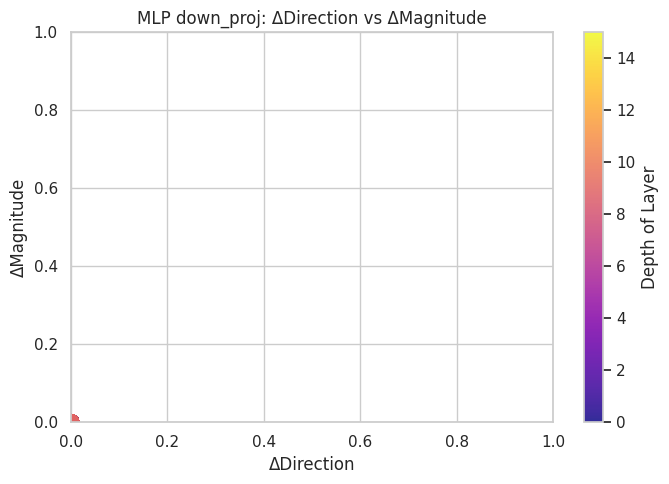

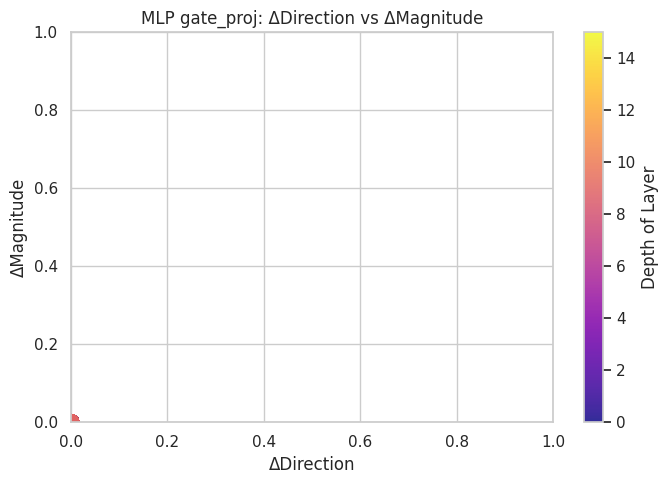

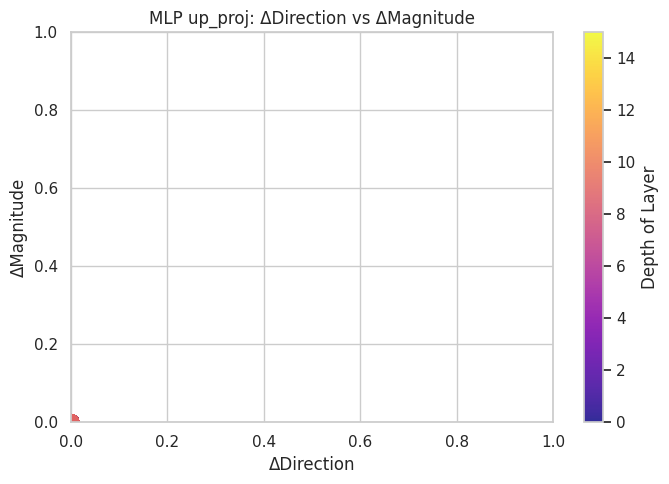

In [1]:
import os
import re
from itertools import combinations
from contextlib import ExitStack

import torch
import torch.nn.functional as F
from safetensors.torch import safe_open
import matplotlib.pyplot as plt
import seaborn as sns

# 路径与运行列表
base_dir = "/cnz/data/project/my-open-unlearning/saves/finetune/consistency_exp/Llama-3.2-1B-Instruct"
run_dirs = sorted(
    [os.path.join(base_dir, d) for d in os.listdir(base_dir) if d.startswith("run")]
)
model_paths = [os.path.join(run_dir, "model.safetensors") for run_dir in run_dirs]
for p in model_paths:
    if not os.path.exists(p):
        raise FileNotFoundError(p)

# 解析层号与 proj 名称
pattern = re.compile(r"model\.layers\.(\d+)\.mlp\.(\w+_proj)\.weight")

# 计算 delta 统计：逐层逐 proj 读取，避免整模型常驻内存
records = []
with ExitStack() as stack:
    handles = [stack.enter_context(safe_open(p, framework="pt")) for p in model_paths]
    keys = [k for k in handles[0].keys() if pattern.match(k)]

    for k in keys:
        m = pattern.match(k)
        layer_idx = int(m.group(1))
        proj_name = m.group(2)

        # 仅保留当前 key 的 5 个 run 权重
        weight_list = [h.get_tensor(k).flatten().float().cpu() for h in handles]

        for i, j in combinations(range(len(weight_list)), 2):
            w_i = weight_list[i]
            w_j = weight_list[j]
            norm_i = torch.norm(w_i)
            norm_j = torch.norm(w_j)
            if norm_i == 0 and norm_j == 0:
                continue
            # 修正：计算绝对相对差异，避免 sequence 顺序影响结果
            delta_mag = torch.abs(norm_i - norm_j) / torch.max(norm_i, norm_j)
            cos_sim = F.cosine_similarity(w_i, w_j, dim=0, eps=1e-8)
            delta_dir = 1.0 - cos_sim
            records.append(
                {
                    "layer": layer_idx,
                    "proj": proj_name,
                    "delta_magnitude": delta_mag.item(),
                    "delta_direction": delta_dir.item(),
                }
            )

        # 主动释放中间张量
        del weight_list

# 将数值裁剪到 0-1 的显示范围
for r in records:
    r["delta_magnitude"] = min(max(r["delta_magnitude"], 0.0), 1.0)
    r["delta_direction"] = min(max(r["delta_direction"], 0.0), 1.0)

# 绘图：每个 proj 单独一个图，颜色表示层深度
sns.set(style="whitegrid")
projs = sorted({r["proj"] for r in records})

for proj in projs:
    xs = [r["delta_direction"] for r in records if r["proj"] == proj]
    ys = [r["delta_magnitude"] for r in records if r["proj"] == proj]
    cs = [r["layer"] for r in records if r["proj"] == proj]

    plt.figure(figsize=(7, 5))
    sc = plt.scatter(xs, ys, c=cs, cmap="plasma", s=120, alpha=0.85)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("ΔDirection")
    plt.ylabel("ΔMagnitude")
    plt.title(f"MLP {proj}: ΔDirection vs ΔMagnitude")
    cbar = plt.colorbar(sc)
    cbar.set_label("Depth of Layer")
    plt.tight_layout()
    plt.show()

# Task Vector 分析（theta_trained - theta_base）

在基座模型参数的基础上，计算每个 run 的 task vector，并对其 $
(\Delta\text{Direction}, \Delta\text{Magnitude})$ 进行同样的统计，同时对每个 `*_proj` 执行 PCA 以观察空间分布差异。

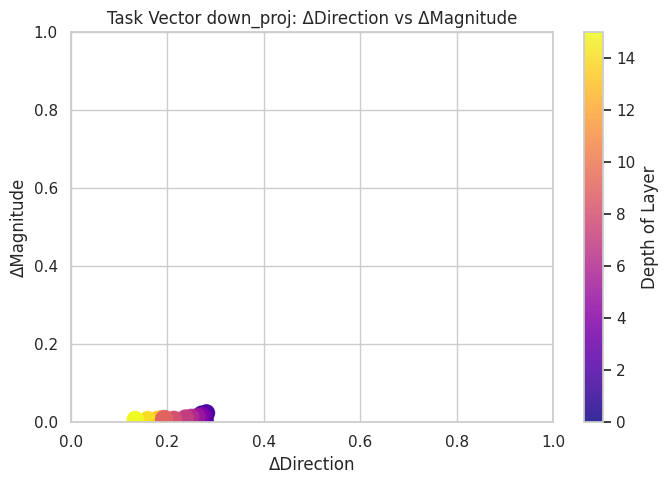

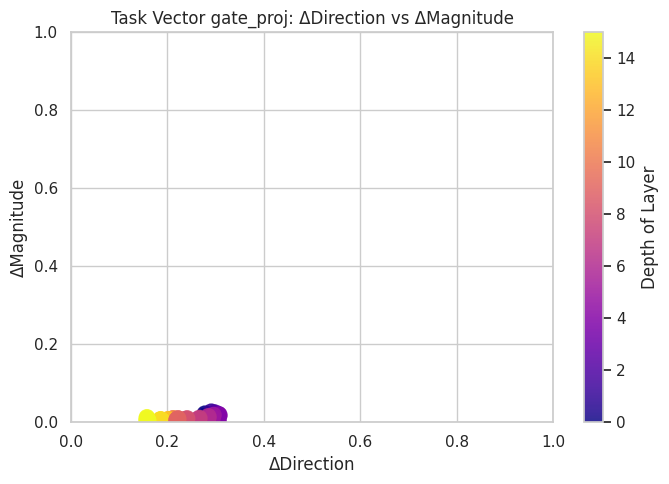

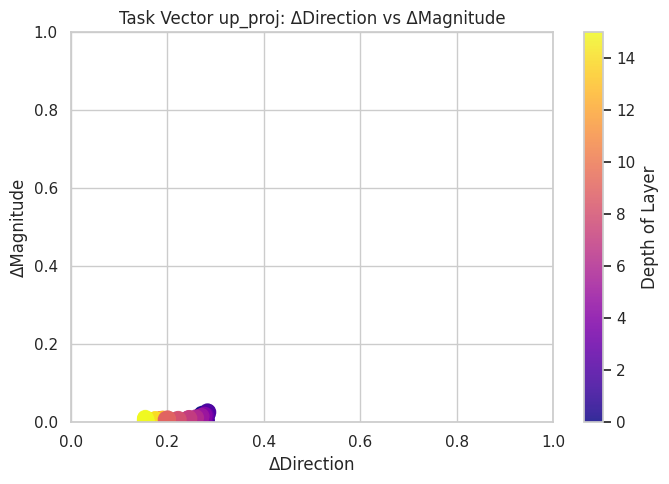

In [2]:
import math
from collections import defaultdict

# 基座模型路径
base_model_path = "/cnz/data/ms-home/Llama-3___2-1B-Instruct/model.safetensors"
if not os.path.exists(base_model_path):
    raise FileNotFoundError(base_model_path)

# 复用前面的 model_paths 和 pattern

# task vector 的 delta 统计 + PCA
records_task = []
pca_data_by_proj = defaultdict(list)  # proj -> list of (vec, layer, run_idx)

with ExitStack() as stack:
    base_handle = stack.enter_context(safe_open(base_model_path, framework="pt"))
    run_handles = [stack.enter_context(safe_open(p, framework="pt")) for p in model_paths]

    keys = [k for k in base_handle.keys() if pattern.match(k)]

    for k in keys:
        m = pattern.match(k)
        layer_idx = int(m.group(1))
        proj_name = m.group(2)

        base_w = base_handle.get_tensor(k).flatten().float().cpu()

        # task vector: trained - base
        task_vectors = [h.get_tensor(k).flatten().float().cpu() - base_w for h in run_handles]

        # delta 统计（对 task vector 进行）
        for i, j in combinations(range(len(task_vectors)), 2):
            w_i = task_vectors[i]
            w_j = task_vectors[j]
            norm_i = torch.norm(w_i)
            norm_j = torch.norm(w_j)
            if norm_i == 0 and norm_j == 0:
                continue
            # 修正：计算绝对相对差异
            delta_mag = torch.abs(norm_i - norm_j) / torch.max(norm_i, norm_j)
            cos_sim = F.cosine_similarity(w_i, w_j, dim=0, eps=1e-8)
            delta_dir = 1.0 - cos_sim
            records_task.append(
                {
                    "layer": layer_idx,
                    "proj": proj_name,
                    "delta_magnitude": delta_mag.item(),
                    "delta_direction": delta_dir.item(),
                }
            )

        # PCA 数据收集（每个 run 都是一个点）
        for run_idx, vec in enumerate(task_vectors):
            pca_data_by_proj[proj_name].append((vec, layer_idx, run_idx))

        # 释放中间张量
        del task_vectors, base_w

# 将数值裁剪到 0-1 的显示范围
for r in records_task:
    r["delta_magnitude"] = min(max(r["delta_magnitude"], 0.0), 1.0)
    r["delta_direction"] = min(max(r["delta_direction"], 0.0), 1.0)

# 绘图：task vector 的 ΔDirection vs ΔMagnitude
sns.set(style="whitegrid")
projs_task = sorted({r["proj"] for r in records_task})

for proj in projs_task:
    xs = [r["delta_direction"] for r in records_task if r["proj"] == proj]
    ys = [r["delta_magnitude"] for r in records_task if r["proj"] == proj]
    cs = [r["layer"] for r in records_task if r["proj"] == proj]

    plt.figure(figsize=(7, 5))
    sc = plt.scatter(xs, ys, c=cs, cmap="plasma", s=120, alpha=0.85)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("ΔDirection")
    plt.ylabel("ΔMagnitude")
    plt.title(f"Task Vector {proj}: ΔDirection vs ΔMagnitude")
    cbar = plt.colorbar(sc)
    cbar.set_label("Depth of Layer")
    plt.tight_layout()
    plt.show()

# PCA 可视化：每个 proj 单独画图
# 使用 torch.pca_lowrank 进行 2D PCA
# for proj, items in pca_data_by_proj.items():
#     if len(items) < 2:
#         continue

#     vecs = [it[0] for it in items]
#     layers = [it[1] for it in items]
#     runs = [it[2] for it in items]

#     X = torch.stack(vecs, dim=0)
#     # 去中心化
#     X = X - X.mean(dim=0, keepdim=True)

#     # 选择 q=2 做低秩 PCA
#     q = 2
#     U, S, V = torch.pca_lowrank(X, q=q)
#     X_2d = X @ V[:, :2]

#     plt.figure(figsize=(7, 5))
#     sc = plt.scatter(
#         X_2d[:, 0].cpu().numpy(),
#         X_2d[:, 1].cpu().numpy(),
#         c=layers,
#         cmap="plasma",
#         s=100,
#         alpha=0.85,
#     )
#     plt.xlabel("PC1")
#     plt.ylabel("PC2")
#     plt.title(f"Task Vector PCA ({proj})")
#     cbar = plt.colorbar(sc)
#     cbar.set_label("Depth of Layer")
#     plt.tight_layout()
#     plt.show()

#     # 释放大张量
#     del X, X_2d, U, S, V

In [10]:
# ICML 论文风格绘图版本：Task Vector 的 ΔDirection vs ΔMagnitude
import matplotlib.pyplot as plt
import seaborn as sns

# 设置 ICML 论文风格配置
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    #"text.usetex": True,  # 如果环境安装了 LaTeX，取消此行注释以获最佳效果
    "mathtext.fontset": "stix"
})

sns.set_style("whitegrid", {"font.family": "serif"})
projs_task = sorted({r["proj"] for r in records_task})

# ICML 单栏宽度约为 3.25 英寸，双栏约为 6.75 英寸。
# 这里 3 并排建议使用较大跨度，方便在双栏页面顶部或底部跨栏显示。
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for i, proj in enumerate(projs_task):
    ax = axes[i]
    xs = [r["delta_direction"] for r in records_task if r["proj"] == proj]
    ys = [r["delta_magnitude"] for r in records_task if r["proj"] == proj]
    cs = [r["layer"] for r in records_task if r["proj"] == proj]

    # 使用 edgecolors='w' 增加点的辨识度，lw 为边框宽度
    sc = ax.scatter(xs, ys, c=cs, cmap="plasma", s=60, alpha=0.8, edgecolors='none')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(r"$\Delta$ Direction", fontsize=11)
    if i == 0:
        ax.set_ylabel(r"$\Delta$ Magnitude", fontsize=11)
    
    # 标题精简
    display_name = proj.replace("_", " ").title()
    ax.set_title(display_name, fontsize=12, fontweight='bold')

# 调整子图间距，为右侧颜色棒留出空间
plt.subplots_adjust(top=0.85, bottom=0.15, left=0.08, right=0.90, wspace=0.1)

# 颜色棒美化
cbar_ax = fig.add_axes([0.92, 0.2, 0.012, 0.6]) 
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Layer Depth Index", fontsize=10)
cbar.ax.tick_params(labelsize=8)

plt.savefig("task_vector_consistency.pdf", bbox_inches='tight')
# 建议在导出时使用 plt.savefig("task_vector_consistency.pdf", bbox_inches='tight')
plt.show()

RuntimeError: Failed to process string with tex because latex could not be found

Error in callback <function _draw_all_if_interactive at 0x7f69c43619e0> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 1400x400 with 4 Axes>

In [5]:
plt.savefig("task_vector_consistency.pdf", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>